# Measure off-resonance from the phase of a single-echo acquisition

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrdistortion/blob/main/examples/02-field_map_from_phase.ipynb)

At echo time TE the signal has already accrued 2.pi.f.TE radians of phase from
off-resonance, so the field is readable directly from the image phase. No search
and no focus metric are involved, and nothing wraps as long as the field stays
under 1/(2.TE) -- which a short echo time makes generous.

What has to be removed first is the coil phase, and that is done by estimating
the sensitivities from these same images: combining with them leaves the phase
that varies faster than the sensitivities do.

In [1]:
try:
    import mrdistortion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "mrdistortion", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrdistortion as mrd

SIZE = 64
ECHO_TIME = 0.7e-3


def acquisition(size: int, coils: int = 8):
    """Coil images of a phantom sitting in a field with two localised lobes."""
    axes = [torch.linspace(-1, 1, size) for _ in range(3)]
    rows, columns, planes = torch.meshgrid(*axes, indexing="ij")
    inside = (rows**2 + columns**2 + planes**2) < 0.8**2
    phantom = inside.float() * (
        1.0 + 0.3 * torch.sin(6 * rows) * torch.cos(5 * columns)
    )

    field = 180 * torch.exp(
        -(((rows - 0.3) ** 2 + (columns - 0.25) ** 2 + planes**2) / 0.03)
    ) - 120 * torch.exp(
        -(((rows + 0.35) ** 2 + (columns + 0.2) ** 2 + planes**2) / 0.03)
    )
    accrued = torch.polar(torch.ones_like(field), 2 * np.pi * field * ECHO_TIME)

    angle = torch.arange(coils) * 2 * np.pi / coils
    images = []
    for centre_row, centre_column in zip(
        1.6 * torch.cos(angle), 1.6 * torch.sin(angle), strict=True
    ):
        distance = (rows - centre_row) ** 2 + (columns - centre_column) ** 2 + planes**2
        sensitivity = torch.polar(torch.exp(-distance / 4.0), 0.5 * distance)
        images.append(phantom * sensitivity * accrued)
    return torch.stack(images), field * inside, inside

8 coils, TE 0.7 ms -> unambiguous +-714 Hz
truth -118 .. +178 Hz
error inside the object: 12.1 Hz mean, 46.4 Hz max


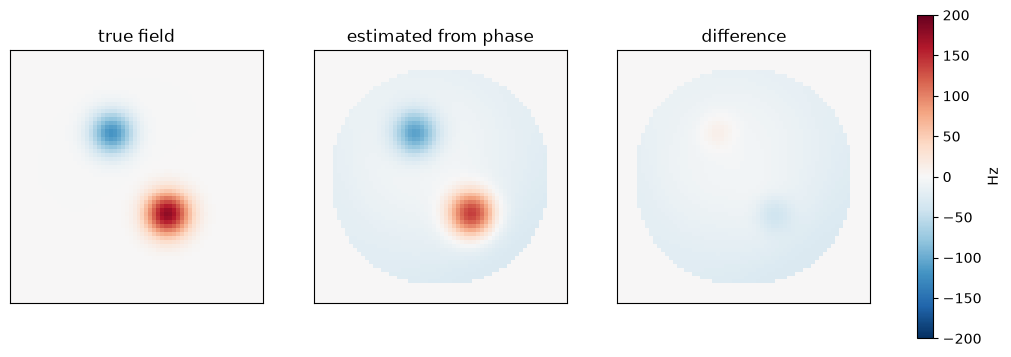

In [3]:
coils, truth, inside = acquisition(SIZE)
print(
    f"{coils.shape[0]} coils, TE {ECHO_TIME * 1e3:.1f} ms "
    f"-> unambiguous +-{1 / (2 * ECHO_TIME):.0f} Hz"
)

estimate = mrd.field_map_from_phase(coils, echo_time=ECHO_TIME, smoothing=1.5)

error = (estimate - truth)[inside]
print(f"truth {truth[inside].min():+.0f} .. {truth[inside].max():+.0f} Hz")
print(
    f"error inside the object: {error.abs().mean():.1f} Hz mean, "
    f"{error.abs().max():.1f} Hz max"
)

middle = SIZE // 2
figure, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for axis, data, title in (
    (axes[0], truth[:, :, middle], "true field"),
    (axes[1], estimate[:, :, middle], "estimated from phase"),
    (axes[2], (estimate - truth)[:, :, middle], "difference"),
):
    shown = axis.imshow(data.numpy(), cmap="RdBu_r", vmin=-200, vmax=200)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
figure.colorbar(shown, ax=axes, fraction=0.025, label="Hz")
figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "field_map_from_phase.png", dpi=110, bbox_inches="tight")